# Support vector classifier: spam detection

In [1]:
# Python standard library imports
import pickle
from pathlib import Path

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from nltk import download as nltk_download
from scipy.stats import randint, uniform, loguniform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

import helper_functions as funcs

nltk_download('stopwords')

RANDOM_SEED = 315
CLASS_WEIGHT = 'balanced'
N_SPLITS = 3

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED
)

# Hyperparameter search settings
N_JOBS = 16
N_ITER = 10000

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/siderealyear/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Data loading

### 1.1. Load data from URL

This section loads the URL spam dataset from a remote source and saves a local copy for reproducibility. We'll also inspect the data structure to understand what we're working with. Having a local copy ensures we can work offline and maintains a stable version of the data throughout the project.

In [2]:
# Read csv file into dataframe
data_df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv')

# Drop duplicates if any
data_df.drop_duplicates(inplace=True)
data_df.reset_index(inplace=True, drop=True)

### 1.2. Save a local copy

In [3]:
# Make a directory for raw data
Path('../data/raw').mkdir(exist_ok=True, parents=True)

# Save a local copy of the raw data
data_df.to_parquet('../data/raw/urls.parquet')

### 1.3. Inspect the data

In [4]:
data_df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2369 non-null   object
 1   is_spam  2369 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 21.0+ KB


**Discussion:** The dataset contains URL strings and binary labels indicating whether each URL is spam. We should check for any missing values or data quality issues before proceeding with analysis.

## 2. EDA

### 2.1. Label frequency

Exploratory Data Analysis helps us understand the dataset's characteristics before modeling. We'll examine the class balance (spam vs. not spam), URL length distributions, and look at edge cases. This analysis informs preprocessing decisions and helps identify potential issues like class imbalance or outliers.

In [6]:
label_counts = data_df['is_spam'].value_counts()

not_spam = label_counts.iloc[0]
spam = label_counts.iloc[1]

print(f'URLs are {(not_spam/(spam + not_spam)*100):.1f}% not spam')

URLs are 89.7% not spam


**Discussion:** The class distribution shows significant imbalance, with the majority of URLs being legitimate (not spam). This imbalance should be considered when training the model - we'll use `class_weight='balanced'` to give more importance to the minority class and prevent the model from simply predicting "not spam" for everything.

### 2.2. URL length distribution

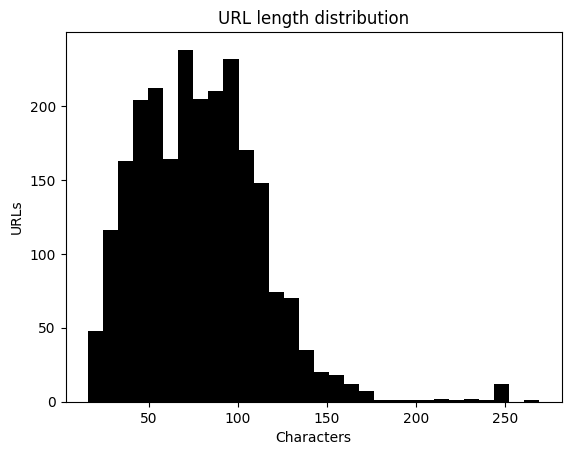

URL length mean: 79
URL length min: 16
URL length max: 269


In [7]:
data_df['URL_length'] = data_df['url'].str.len().tolist()

plt.title('URL length distribution')
plt.xlabel('Characters')
plt.ylabel('URLs')
plt.hist(data_df['URL_length'], bins=30, color='black')
plt.show()

print(f"URL length mean: {np.mean(data_df['URL_length']):.0f}")
print(f"URL length min: {min(data_df['URL_length']):.0f}")
print(f"URL length max: {max(data_df['URL_length']):.0f}")

**Discussion:** URL lengths vary considerably, from very short to quite long. The distribution appears roughly normal with some long outliers. This variation suggests URLs contain different amounts of information, which TF-IDF vectorization should capture effectively.

### 2.3. Short URLs

In [8]:
short_urls = data_df[data_df['URL_length'] < 20]
short_urls

,url,is_spam,URL_length
150,https://neeva.co/,False,17
656,https://qz.com/app/,False,19
676,https://digg.com/,True,17
728,https://uqora.com/,True,18
963,https://tim.blog/,True,17
971,http://abw.blue/,False,16
978,https://mowned.com/,False,19
995,https://waxy.org/,True,17
1158,https://hey.com/,True,16
1469,https://woven.com/,False,18


**Discussion:** Very short URLs may represent legitimate shortened links or simple domain names. These could be challenging to classify since they contain minimal information for the model to learn from.

### 2.4. Long URLs

In [9]:
long_urls = data_df[data_df['URL_length'] > 200]
long_urls

,url,is_spam,URL_length
472,https://www.youtube.com/watch?v=4An0ndagZsQ&fe...,False,244
479,https://www.youtube.com/watch?v=oieBnV_HFB0&fe...,False,244
480,https://www.youtube.com/watch?v=PQmDUEv939A&fe...,False,244
481,https://www.youtube.com/watch?v=QrGEIWe0JXY&fe...,False,244
587,https://www.youtube.com/watch?v=S0qrinhNnOM&fe...,False,244
663,https://www.youtube.com/watch?v=gbCREJh6aCc&fe...,False,244
914,https://www.npr.org/sections/live-updates-prot...,False,269
1285,https://www.youtube.com/watch?v=SrLZgP-OR6s&ut...,False,227
1286,https://www.youtube.com/watch?v=N13WI3oVda8&ut...,False,227
1290,https://www.youtube.com/watch?v=Yz3mQhuMACs&fe...,False,244


**Discussion:** Extremely long URLs often contain many parameters and encoded values. Spam URLs might use obfuscation techniques with long query strings, making length a potentially useful feature for classification.

## 3. Data preprocessing

Data preprocessing prepares our text data for machine learning. We'll encode labels as integers, split into train/test sets, and convert URLs into numerical features using TF-IDF vectorization. TF-IDF captures the importance of each word/character in the URLs, which is essential for the SVM to learn patterns that distinguish spam from legitimate URLs.

### 3.1. Label encoding

In [10]:
data_df['is_spam'] = data_df['is_spam'].astype(str)
data_df['is_spam'] = data_df['is_spam'].replace({'True': '1', 'False': '0'})
data_df['is_spam'] = data_df['is_spam'].astype(int)

### 3.2. Train test split

In [11]:
train_df, test_df = train_test_split(data_df, test_size=0.3, random_state=RANDOM_SEED)

### 3.3. URL vectorization

In [12]:
# Vectorize the URLs using TF-IDF
vectorizer = TfidfVectorizer()
train_urls = vectorizer.fit_transform(train_df['url'])
test_urls = vectorizer.transform(test_df['url'])

# Get the words from the vector model
feature_names = vectorizer.get_feature_names_out()
print(f'Example feature names: {feature_names[:10]}')

Example feature names: ['0027' '003722' '01' '01838' '01864' '01891' '01906' '01908' '02' '020']


**Discussion:** TF-IDF vectorization has transformed the URLs into numerical features. The feature names represent individual characters and character sequences extracted from the URLs. Each URL is now represented as a sparse vector where values indicate the importance of each character/sequence in that particular URL.

### 3.4. Mean TF-IDF value distribution

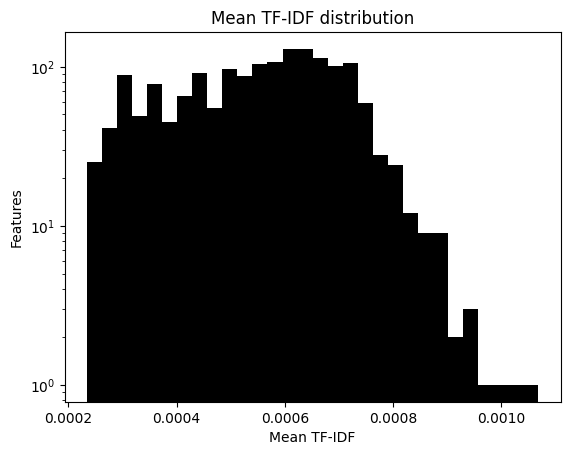

In [13]:
# Get the mean TF-IDF value for each feature
feature_means = np.mean(train_urls.toarray(), axis=1)

plt.title('Mean TF-IDF distribution')
plt.xlabel('Mean TF-IDF')
plt.ylabel('Features')
plt.hist(feature_means, bins=30, color='black')
plt.yscale('log')
plt.show()

**Discussion:** Most features have low mean TF-IDF values (note the log scale on y-axis), which is typical. This indicates that most character sequences appear infrequently across URLs. Features with higher values are more common across the dataset and may represent standard URL components like "http", "www", or common domain patterns.

## 3. SVM model

### 3.1. Baseline model performance

We'll train Support Vector Machine models with increasing sophistication. First, we establish a baseline with default hyperparameters to understand basic performance. Then we optimize the SVC hyperparameters, and finally optimize both the vectorizer and classifier together in a pipeline. This progressive approach helps us understand which optimizations provide the most value.

In [14]:
# Instantiate the support vector machine classifier with defaults
naive_svc = SVC(class_weight=CLASS_WEIGHT, random_state=RANDOM_SEED)

# Cross-validate the default model on the encoded training data
scores = cross_val_score(
    naive_svc,
    train_urls,
    train_df['is_spam'],
    cv=CV,
    n_jobs=-1
)

# Save the baseline cross-validation scores for later
cross_val_scores = {
    'Model': ['Naive SVC']*N_SPLITS,
    'Score': list(scores)
}

print(f'Naive SVC cross validation accuracy: {np.mean(scores)*100:.1f}+/-{np.std(scores)*100:.1f}%')

Naive SVC cross validation accuracy: 93.4+/-1.1%


**Discussion:** The baseline SVC model achieves reasonable performance with default hyperparameters. The cross-validation score provides a more reliable estimate than a single train/test split. The standard deviation indicates consistency across folds, suggesting the model generalizes well.

In [15]:
model = SVC(class_weight=CLASS_WEIGHT, random_state=RANDOM_SEED)
model.fit(train_urls, train_df['is_spam'])
print(f'Training accuracy: {model.score(train_urls, train_df['is_spam'])*100:.1f}%')
print(f'Testing accuracy: {model.score(test_urls, test_df['is_spam'])*100:.1f}%')


Training accuracy: 99.6%
Testing accuracy: 92.3%


**Discussion:** The training accuracy is significantly higher than testing accuracy, indicating some overfitting. This is expected with default parameters. Hyperparameter tuning should help reduce this gap and improve generalization.

### 3.2. SVC hyperparameter optimization

In [16]:
# Set the hyperparameter search space
hyperparameters = {
    'C': uniform(loc=0.001, scale=99.999),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto'],
    'shrinking': [True, False],
    'decision_function_shape': ['ovo', 'ovr']
}

# Instantiate a new model
model = SVC(class_weight=CLASS_WEIGHT, random_state=RANDOM_SEED)

grid = RandomizedSearchCV(
    model,
    hyperparameters,
    return_train_score=True,     # Return training scores for analysis
    cv=CV,                       # Use stratified shuffle split for cross-validation
    n_jobs=N_JOBS,               # Use all available CPU cores
    n_iter=N_ITER,               # Number of parameter combinations to try
    random_state=RANDOM_SEED     # Ensure reproducible results
)

# Run the search
optimization_results = grid.fit(train_urls, train_df['is_spam'])

# Recover winning model & hyperparameters
optimized_svc = grid.best_estimator_
best_hyperparameters = grid.best_params_

print(f'Best hyperparameters:\n')

for key, val in best_hyperparameters.items():
    print(f' {key}: {val}')

Best hyperparameters:

 C: 0.6101712342777198
 decision_function_shape: ovo
 degree: 3
 gamma: auto
 kernel: linear
 shrinking: True


**Discussion:** Hyperparameter optimization explored a wide range of SVC configurations. The winning combination represents the best trade-off between model complexity and generalization. The specific kernel and C value tell us about the decision boundary complexity that works best for this problem.

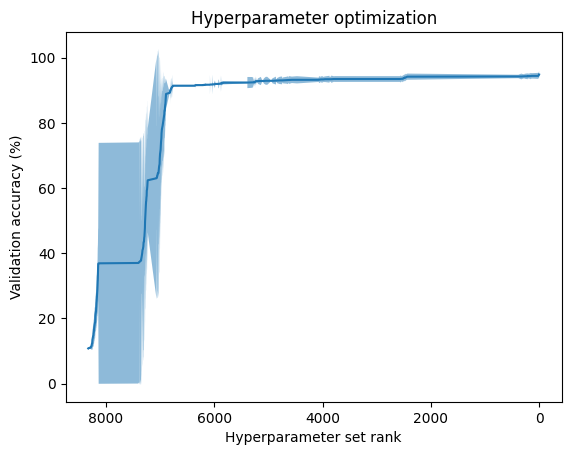

In [17]:
funcs.plot_cross_validation(optimization_results)

In [18]:
# Cross-validate the optimized model on the encoded training data
scores = cross_val_score(
    optimized_svc,
    train_urls,
    train_df['is_spam'],
    cv=CV,
    n_jobs=-1
)

# Save the optimized cross-validation scores for later
cross_val_scores['Model'].extend(['Optimized SVC']*N_SPLITS)
cross_val_scores['Score'].extend(scores)

print(f'Optimized SVC cross validation accuracy: {np.mean(scores)*100:.1f}+/-{np.std(scores)*100:.1f}%')

Optimized SVC cross validation accuracy: 94.8+/-1.1%


**Discussion:** Comparing the optimized model's cross-validation scores to the baseline shows whether hyperparameter tuning improved performance. A meaningful improvement would suggest the default parameters were suboptimal for this specific dataset.

In [19]:
optimized_svc.fit(train_urls, train_df['is_spam'])
print(f'Training accuracy: {optimized_svc.score(train_urls, train_df['is_spam'])*100:.1f}%')
print(f'Testing accuracy: {optimized_svc.score(test_urls, test_df['is_spam'])*100:.1f}%')

Training accuracy: 98.8%
Testing accuracy: 90.4%


**Discussion:** The train/test accuracy gap is an important indicator of model generalization. A smaller gap compared to the baseline model suggests the optimized hyperparameters have reduced overfitting. Testing accuracy is the most important metric for real-world deployment.

### 3.3. TFIDFVectorizer + SVC hyperparameter optimization

In [20]:
tfidf = TfidfVectorizer()
svc = SVC(class_weight=CLASS_WEIGHT, random_state=RANDOM_SEED)

# Create pipeline with PCA, scaling, and classifier
pipe = Pipeline(steps=[('TFIDF', tfidf), ('SVC', svc)])

hyperparameters = {
    'TFIDF__strip_accents': ['ascii', 'unicode', None],
    'TFIDF__stop_words': ['english', stopwords.words('english'), None],
    'TFIDF__ngram_range': [(1,1), (1,2), (2,2)],
    'TFIDF__max_df': uniform(loc=0.0009, scale=0.9991),
    'TFIDF__min_df': uniform(loc=0.0, scale=0.0004),
    'TFIDF__max_features': randint(1, len(feature_names)),
    'TFIDF__binary': [True, False],
    'TFIDF__norm': ['l1', 'l2', None],
    'TFIDF__use_idf': [True, False],
    'TFIDF__smooth_idf': [True, False],
    'TFIDF__sublinear_tf': [True, False],
    'SVC__C': loguniform(10**-2, 100.0),
    'SVC__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'SVC__degree': [1, 2, 3],
    'SVC__gamma': ['scale', 'auto'],
    'SVC__shrinking': [True, False],
    'SVC__decision_function_shape': ['ovo', 'ovr']
}

grid = RandomizedSearchCV(
    pipe,
    hyperparameters,
    return_train_score=True,     # Return training scores for analysis
    cv=CV,                       # Use stratified shuffle split for cross-validation
    n_jobs=N_JOBS,               # Use all available CPU cores
    n_iter=N_ITER,               # Number of parameter combinations to try
    random_state=RANDOM_SEED     # Ensure reproducible results
)

# Run the search
optimization_results = grid.fit(train_df['url'], train_df['is_spam'])

# Recover winning model & hyperparameters
optimized_tfidf_svc = grid.best_estimator_
best_hyperparameters = grid.best_params_

print(f'Best hyperparameters:\n')

for key, val in best_hyperparameters.items():
    print(f' {key}: {val}')

Best hyperparameters:

 SVC__C: 7.427110351755111
 SVC__decision_function_shape: ovr
 SVC__degree: 2
 SVC__gamma: scale
 SVC__kernel: rbf
 SVC__shrinking: True
 TFIDF__binary: False
 TFIDF__max_df: 0.5655105036759216
 TFIDF__max_features: 3818
 TFIDF__min_df: 0.00016401798475564018
 TFIDF__ngram_range: (1, 1)
 TFIDF__norm: l2
 TFIDF__smooth_idf: False
 TFIDF__stop_words: english
 TFIDF__strip_accents: None
 TFIDF__sublinear_tf: False
 TFIDF__use_idf: False


**Discussion:** This comprehensive optimization explores both feature extraction (TFIDF) and classification (SVC) parameters simultaneously. The pipeline approach ensures the vectorizer is optimized specifically for the chosen classifier configuration. This can yield better performance than optimizing components independently.

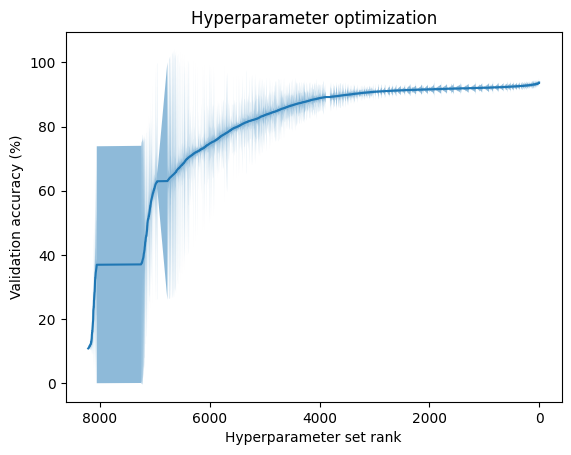

In [21]:
funcs.plot_cross_validation(optimization_results)

In [22]:
# Cross-validate the optimized model on the encoded training data
scores = cross_val_score(
    optimized_tfidf_svc,
    train_df['url'],
    train_df['is_spam'],
    cv=CV,
    n_jobs=-1
)

# Save the optimized cross-validation scores for later
cross_val_scores['Model'].extend(['Optimized TFIDF + SVC']*N_SPLITS)
cross_val_scores['Score'].extend(scores)

print(f'Optimized TFIDF + SVC cross validation accuracy: {np.mean(scores)*100:.1f}+/-{np.std(scores)*100:.1f}%')

Optimized TFIDF + SVC cross validation accuracy: 93.7+/-0.6%


**Discussion:** Comparing this pipeline approach to the previous optimized model reveals whether jointly optimizing vectorization and classification provides additional benefit. The cross-validation scores indicate the most reliable model for deployment.

In [23]:
optimized_tfidf_svc.fit(train_df['url'], train_df['is_spam'])
print(f'Training accuracy: {optimized_tfidf_svc.score(train_df['url'], train_df['is_spam'])*100:.1f}%')
print(f'Testing accuracy: {optimized_tfidf_svc.score(test_df['url'], test_df['is_spam'])*100:.1f}%')

Training accuracy: 98.9%
Testing accuracy: 90.4%


**Discussion:** These final accuracy scores on train and test sets show the ultimate performance of the fully optimized pipeline. The relationship between training and testing accuracy indicates how well the model will perform on new, unseen URLs.

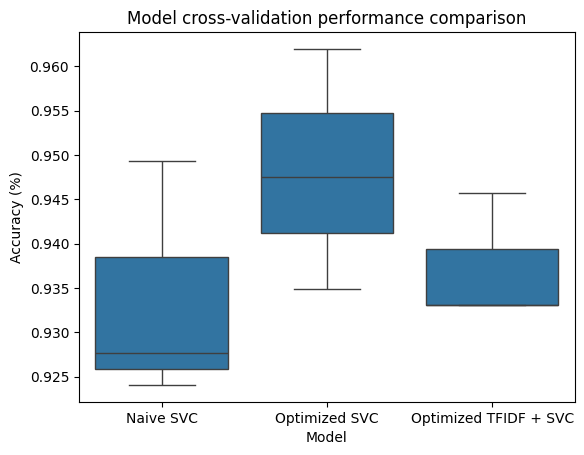

In [24]:
sns.boxplot(pd.DataFrame.from_dict(cross_val_scores), x='Model', y='Score')
plt.title('Model cross-validation performance comparison')
plt.ylabel('Accuracy (%)')
plt.show()

**Discussion:** The boxplot comparison visualizes performance differences across all three approaches. Consistent performance across cross-validation folds (tight boxes) indicates robust models. The best-performing model balances high accuracy with low variance for reliable predictions.

## 4. Model evaluation

Final model evaluation on the held-out test set provides an unbiased estimate of real-world performance. The confusion matrix visualization helps us understand not just overall accuracy, but also the types of errors the model makes (false positives vs. false negatives), which is crucial for spam detection applications.

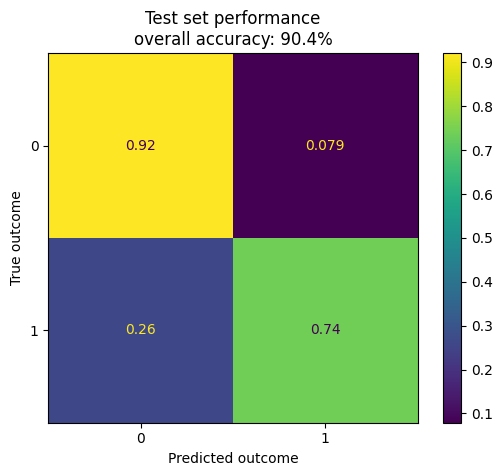

In [25]:
optimized_svc.fit(train_urls, train_df['is_spam'])
predictions = optimized_svc.predict(test_urls)

accuracy = accuracy_score(test_df['is_spam'], predictions)*100

# Plot the confusion matrix
cm = confusion_matrix(test_df['is_spam'], predictions, normalize='true')
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm)
_ = cm_disp.plot()

plt.title(f'Test set performance\noverall accuracy: {accuracy:.1f}%')
plt.xlabel('Predicted outcome')
plt.ylabel('True outcome')
plt.show()

**Discussion:** The confusion matrix reveals the model's error patterns. For spam detection, false negatives (spam marked as legitimate) and false positives (legitimate URLs marked as spam) have different real-world costs. The normalized values show the proportion of each class correctly classified, which is especially important given our class imbalance.

## 5. Save assets

Saving the trained model and vectorizer allows us to deploy the spam detector in production without retraining. Both components are essential: the vectorizer transforms new URLs into the same feature space used during training, and the model makes predictions on those features.

In [26]:
with open('../models/svc_vectorizer.pkl', 'wb') as output_file:
    pickle.dump(vectorizer, output_file)

with open('../models/optimized_svc.pkl', 'wb') as output_file:
    pickle.dump(optimized_svc, output_file)

**Discussion:** Both components have been successfully saved to the models directory. To use this spam detector in production, load both the vectorizer and model, then transform new URLs with the vectorizer before passing them to the model for prediction. This ensures consistency between training and inference.